# Интеллектуальный анализ данных – весна 2025
# Домашнее задание 6: классификация текстов

Правила:



*   Домашнее задание оценивается в 10 баллов.
*   Можно использовать без доказательства любые результаты, встречавшиеся на лекциях или семинарах по курсу, если получение этих результатов не является вопросом задания.
*  Можно использовать любые свободные источники с *обязательным* указанием ссылки на них.
*  Плагиат не допускается. При обнаружении случаев списывания, 0 за работу выставляется всем участникам нарушения, даже если можно установить, кто у кого списал.
*  Старайтесь сделать код как можно более оптимальным. В частности, будет штрафоваться использование циклов в тех случаях, когда операцию можно совершить при помощи инструментов библиотек, о которых рассказывалось в курсе.
* Если в задании есть вопрос на рассуждение, то за отсутствие ответа на него балл за задание будет снижен вполовину.

В этом домашнем задании вам предстоит построить классификатор текстов.

Будем предсказывать эмоциональную окраску твиттов о коронавирусе.



In [1]:
import numpy as np
import pandas as pd
from typing import  List
import matplotlib.pyplot as plt
import seaborn as sns
from string import punctuation

In [2]:
df = pd.read_csv(r'https://raw.githubusercontent.com/hse-ds/iad-intro-ds/refs/heads/master/2025/homeworks/hw06_texts/tweets_coronavirus.csv', encoding='latin-1')
df.sample(4)

,UserName,ScreenName,Location,TweetAt,OriginalTweet,Sentiment
25509,35044,79996,Morris County NJ,06-04-2020,Finally the supermarket where my son works has...,Positive
28260,38454,83406,NaN,08-04-2020,@retofrei5 @qatarairways You canÃÂt because ...,Positive
14050,20854,65806,"Barcelona, Spain",23-03-2020,The most important thing we should be doing is...,Extremely Negative
19290,27279,72231,"Riyadh, Saudi Arabia",26-03-2020,prices slipped back in Asian trade on Thursday...,Positive


Для каждого твитта указано:


*   UserName - имя пользователя, заменено на целое число для анонимности
*   ScreenName - отображающееся имя пользователя, заменено на целое число для анонимности
*   Location - местоположение
*   TweetAt - дата создания твитта
*   OriginalTweet - текст твитта
*   Sentiment - эмоциональная окраска твитта (целевая переменная)



## Задание 1 Подготовка (0.5 балла)

Целевая переменная находится в колонке `Sentiment`.  Преобразуйте ее таким образом, чтобы она стала бинарной: 1 - если у твитта положительная или очень положительная эмоциональная окраска и 0 - если отрицательная или очень отрицательная.

In [3]:
df['Sentiment'].unique()

array(['Positive', 'Extremely Negative', 'Negative', 'Extremely Positive'],
      dtype=object)

In [4]:
df['Sentiment'] = df['Sentiment'].apply(lambda x: 1 if x in ['Positive', 'Extremely Positive'] else 0)
df['Sentiment'].sample(5)

27512    1
23506    1
21653    0
7382     1
765      1
Name: Sentiment, dtype: int64

Сбалансированы ли классы?

In [5]:
df['Sentiment'].value_counts(normalize=True) * 100

Sentiment
1    53.958857
0    46.041143
Name: proportion, dtype: float64

**Ответ:** видимо нет, положительных немного больше.

Выведете на экран информацию о пропусках в данных. Если пропуски присутствуют заполните их строкой 'Unknown'.

In [6]:
print(f'Пропуски есть в колонке {df.isna().sum().idxmax()}. Их количество составляет {df.isna().sum()['Location']}')

Пропуски есть в колонке Location. Их количество составляет 7049


In [7]:
from sklearn.impute import SimpleImputer

imputer = SimpleImputer(strategy='constant', fill_value='Unknown')
imputer.set_output(transform='pandas')
df = imputer.fit_transform(df)
df.sample(5)

,UserName,ScreenName,Location,TweetAt,OriginalTweet,Sentiment
5236,10168,55120,Unknown,19-03-2020,Great idea ToV businesses are the best Continu...,1
13625,20329,65281,"Manchester, NJ",22-03-2020,"Kroger, country's largest supermarket chain ha...",0
15729,22923,67875,"Headquarters: Dallas, TX",24-03-2020,How will judges view cancellations of trips or...,0
25404,34912,79864,Australia,06-04-2020,Covid_19 observations. \r\r\nMy shopping exper...,1
13526,20212,65164,"Punjab, Pakistan",22-03-2020,Chinese : Wear Mask\r\r\nItaly : Stay At Home\...,1


Разделите данные на обучающие и тестовые в соотношении 7 : 3 и укажите `random_state=0`

In [8]:
from sklearn.model_selection import train_test_split

# X = df.drop(columns=['Sentiment'])
# y = df['Sentiment']

train, test = train_test_split(df, test_size=0.3, random_state=0)
# y_train.value_counts(normalize=True), y_test.value_counts(normalize=True)

## Задание 2 Токенизация (3 балла)

Постройте словарь на основе обучающей выборки и посчитайте количество встреч каждого токена с использованием самой простой токенизации - деления текстов по пробельным символам и приведения токенов в нижний регистр.

In [9]:
import nltk
from nltk.tokenize import WhitespaceTokenizer
from collections import Counter

# nltk.download("punkt_tab", quiet=True)

In [10]:
train['OriginalTweet'] = train['OriginalTweet'].str.lower()

In [11]:
tokenizer = WhitespaceTokenizer()
text = ' '.join(train['OriginalTweet'])
slovar = Counter(tokenizer.tokenize(text))
# print(len(slovar))

Какой размер словаря получился?

In [12]:
print(len(slovar))

79755


Выведите 10 самых популярных токенов с количеством встреч каждого из них. Объясните, почему именно эти токены в топе.

In [13]:
for kortez in slovar.most_common(10):
    print(f'Токен - {kortez[0]}, кол-во встреч - {kortez[1]}')

Токен - the, кол-во встреч - 26815
Токен - to, кол-во встреч - 23373
Токен - and, кол-во встреч - 14684
Токен - of, кол-во встреч - 13012
Токен - a, кол-во встреч - 11737
Токен - in, кол-во встреч - 11198
Токен - for, кол-во встреч - 8566
Токен - #coronavirus, кол-во встреч - 8223
Токен - is, кол-во встреч - 7383
Токен - are, кол-во встреч - 7050


**Ответ:** Потому что это просто предлоги и самые популярные глаголы, которые в англе через каждое слово тыкают. Ну и хештег коронавирус в выборке про коронавирус тоже очев частенько будет попадаться. 

Удалите стоп-слова из словаря и выведите новый топ-10 токенов (и количество встреч) по популярности.  Что можно сказать  о нем?

In [14]:
from nltk.corpus import stopwords
nltk.download("stopwords", quiet=True)

stopwords = stopwords.words('English')
filtered_slovar = {slovo: count for slovo, count in slovar.items() if slovo not in stopwords}
for kortez in sorted(filtered_slovar.items(), key=lambda x: x[1], reverse=True)[:10]:
    print(f'Токен - {kortez[0]}, кол-во встреч - {kortez[1]}')


Токен - #coronavirus, кол-во встреч - 8223
Токен - prices, кол-во встреч - 3891
Токен - food, кол-во встреч - 3820
Токен - grocery, кол-во встреч - 3469
Токен - supermarket, кол-во встреч - 3288
Токен - people, кол-во встреч - 3175
Токен - covid-19, кол-во встреч - 3173
Токен - store, кол-во встреч - 3155
Токен - #covid19, кол-во встреч - 2471
Токен - &amp;, кол-во встреч - 2314


**Ответ:**  ну в целом логично, что самые популярные слова после предлогов это слова, которые связаны с социальными потрясениями из-за ковида. Ну хештег ковид очев, ну а дальше бабки, еда супермаркеты, люди, магазины и так далее.

Также выведите 20 самых непопулярных слов (если самых непопулярных слов больше, выведите любые 20 из них) Почему эти токены непопулярны, требуется ли как-то дополнительно работать с ними?

In [15]:
for kortez in sorted(filtered_slovar.items(), key=lambda x: x[1], reverse=True)[-10:]:
    print(f'Токен - {kortez[0]}, кол-во встреч - {kortez[1]}')

Токен - non-playing, кол-во встреч - 1
Токен - subsidise, кол-во встреч - 1
Токен - playersãâ, кол-во встреч - 1
Токен - renewing, кол-во встреч - 1
Токен - wage!, кол-во встреч - 1
Токен - flew, кол-во встреч - 1
Токен - nothing..., кол-во встреч - 1
Токен - @torontopearson, кол-во встреч - 1
Токен - @680news, кол-во встреч - 1
Токен - https://t.co/7j2y3rsld9, кол-во встреч - 1


**Ответ:** Ну это какие-то рофло ссылки, ошибочные слова или слова, которые рандомно выписаны один раз по приколу. Вероятно, такие токены лучше просто скипать и удалять из словаря и никак не закидывать их в модельку, чтобы не создавать лишнего шума.



Теперь воспользуемся токенайзером получше - TweetTokenizer из библиотеки nltk. Примените его и посмотрите на топ-10 популярных слов. Чем он отличается от топа, который получался раньше? Почему?

In [16]:
from nltk.tokenize import TweetTokenizer
from collections import Counter

tweeter_tokenizer = TweetTokenizer()
tweeter_tokenized = tweeter_tokenizer.tokenize(text)
tweeter_slovar = Counter(tweeter_tokenized)
tweeter_slovar.most_common(10)

[('the', 26993),
 ('.', 24108),
 ('to', 23478),
 (',', 17571),
 ('and', 14825),
 ('of', 13044),
 ('a', 11891),
 ('in', 11348),
 ('?', 9524),
 ('#coronavirus', 8808)]

**Ответ:** Ну тут знаков препинания отчетливо больше, т.к. этот токенайзер учитывает всякие эмодзи, повторения символов, хэштеги и т.д., а это всё сооружается за счёт знаков препинания.

Удалите из словаря стоп-слова и пунктуацию, посмотрите на новый топ-10 слов с количеством встреч, есть ли теперь в нем что-то не похожее на слова?

In [17]:
from string import punctuation

filtered_tweeter_slovar = {token: count for token, count in tweeter_slovar.items() if token.lower() not in stopwords + list(punctuation)}
for kortez in sorted(filtered_tweeter_slovar.items(), key=lambda x: x[1], reverse=True)[:10]:
    print(f'Токен - {kortez[0]}, кол-во встреч - {kortez[1]}')

Токен - #coronavirus, кол-во встреч - 8808
Токен - â, кол-во встреч - 7415
Токен - , кол-во встреч - 7311
Токен - 19, кол-во встреч - 7167
Токен - covid, кол-во встреч - 6253
Токен - prices, кол-во встреч - 4601
Токен - , кол-во встреч - 4372
Токен - food, кол-во встреч - 4367
Токен - store, кол-во встреч - 3877
Токен - supermarket, кол-во встреч - 3805


**Ответ:** Да, заспавнились какие-то не очень понятные символы, может быть это какие-то смайлики, которые при указание некоторой кодировки превращаются вот в такое.

Скорее всего в некоторых топах были неотображаемые символы или отдельные буквы не латинского алфавита. Уберем их: удалите из словаря токены из одного символа, позиция которого в таблице Unicode 128 и более (`ord(x) >= 128`)

Выведите топ-10 самых популярных и топ-20 непопулярных слов. Чем полученные топы отличаются от итоговых топов, полученных при использовании токенизации по пробелам? Что теперь лучше, а что хуже?

In [18]:
filtered_tweeter_ord_slovar = {token: count for token, count in filtered_tweeter_slovar.items() if len(token) > 1 or
                               ord(token) < 128}
print('Топ 10 самых популярных слов:')
for kortez in sorted(filtered_tweeter_ord_slovar.items(), key=lambda x: x[1], reverse=True)[:10]:
    print(f'Токен - {kortez[0]}, кол-во встреч - {kortez[1]}')
print()
print('Топ 10 самых непопулярных слов:')
for kortez in sorted(filtered_tweeter_ord_slovar.items(), key=lambda x: x[1], reverse=True)[-20:]:
    print(f'Токен - {kortez[0]}, кол-во встреч - {kortez[1]}')

Топ 10 самых популярных слов:
Токен - #coronavirus, кол-во встреч - 8808
Токен - 19, кол-во встреч - 7167
Токен - covid, кол-во встреч - 6253
Токен - prices, кол-во встреч - 4601
Токен - food, кол-во встреч - 4367
Токен - store, кол-во встреч - 3877
Токен - supermarket, кол-во встреч - 3805
Токен - grocery, кол-во встреч - 3523
Токен - people, кол-во встреч - 3463
Токен - #covid19, кол-во встреч - 2589

Топ 10 самых непопулярных слов:
Токен - https://t.co/lw1r0rm7xs, кол-во встреч - 1
Токен - https://t.co/5cbliqzx7l, кол-во встреч - 1
Токен - now.when, кол-во встреч - 1
Токен - milion, кол-во встреч - 1
Токен - skellig, кол-во встреч - 1
Токен - @skelligsix18, кол-во встреч - 1
Токен - #skelligcoast2kms, кол-во встреч - 1
Токен - #southkerry, кол-во встреч - 1
Токен - https://t.co/zjcl195vqs, кол-во встреч - 1
Токен - @srinivasiyc, кол-во встреч - 1
Токен - https://t.co/iaek4fwsgz, кол-во встреч - 1
Токен - premiership, кол-во встреч - 1
Токен - non-playing, кол-во встреч - 1
Токен - s

**Ответ:** Теперь совсем хорошо. Топ популярных слов чистый, нет смешных односимвольных непоняток, топ непопулярных тоже хороший, там теперь почти нет ошибочных слов, выделяются только ссылки или например слова с началом через @, что вероятно обозначает название аккаунта.

Выведите топ-10 популярных хештегов (токены, первые символы которых - #) с количеством встреч. Что можно сказать о них?

In [19]:
slovar_hashtagov = {}
for token, count in filtered_tweeter_ord_slovar.items():
    if token.startswith('#'):
        slovar_hashtagov[token] = count
        
slovar_hashtagov = Counter(slovar_hashtagov)
for kortez in sorted(slovar_hashtagov.items(), key=lambda x: x[1], reverse=True)[:10]:
    print(f'Токен - {kortez[0]}, кол-во встреч - {kortez[1]}')

Токен - #coronavirus, кол-во встреч - 8808
Токен - #covid19, кол-во встреч - 2589
Токен - #covid_19, кол-во встреч - 1734
Токен - #covid2019, кол-во встреч - 946
Токен - #toiletpaper, кол-во встреч - 744
Токен - #covid, кол-во встреч - 641
Токен - #socialdistancing, кол-во встреч - 465
Токен - #coronacrisis, кол-во встреч - 448
Токен - #pandemic, кол-во встреч - 257
Токен - #coronaviruspandemic, кол-во встреч - 249


**Ответ:** про них можно сказать, что они почти все просто отражают суть датасета - ковид, пандемия, социальное дистанцирование и т.д. Но а хештег #toiletpaper напрямую отражает потерю потерь для всего человества, т.к. видимо произошел резкий дефицит

То же самое проделайте для ссылок на сайт https://t.co Сравнима ли популярность ссылок с популярностью хештегов? Будет ли информация о ссылке на конкретную страницу полезна?

In [20]:
counter = 0
for token, count in sorted(filtered_tweeter_ord_slovar.items(), key=lambda x: x[1], reverse=True):
    if counter < 10 and token.startswith('https://t.co'):
        print(f'Токен - {token}, кол-во встреч - {count}')
        counter +=1
    else:
        continue

Токен - https://t.co/oxa7swtond, кол-во встреч - 5
Токен - https://t.co/gp3eusapl8, кол-во встреч - 4
Токен - https://t.co/deftrui1pfãâ, кол-во встреч - 3
Токен - https://t.co/wrlhyzizaa, кол-во встреч - 3
Токен - https://t.co/kuwipf1kqw, кол-во встреч - 3
Токен - https://t.co/zjnrx6dkkn, кол-во встреч - 3
Токен - https://t.co/3gbbdpdjat, кол-во встреч - 3
Токен - https://t.co/e2znxajpre, кол-во встреч - 3
Токен - https://t.co/catkegayoy, кол-во встреч - 3
Токен - https://t.co/g63rp042ho, кол-во встреч - 3


**Ответ:** Какие-то рандомные ссылки на рандомные твитты с очень низким количеством появлений, вообще бесполезная информация.

Используем опыт предыдущих экспериментов и напишем собственный токенайзер, улучшив TweetTokenizer. Функция tokenize должна:



*   Привести текст в нижний регистр
*   Применить TweetTokenizer для  выделения токенов
*   Удалить стоп-слова, пунктуацию, токены из одного символа с позицией в таблице Unicode 128 и более,  ссылки на t.co



In [21]:
from string import punctuation
from nltk.tokenize import TweetTokenizer

def custom_tokenizer(text: str):
  tokenizer = TweetTokenizer()
  tokens = tokenizer.tokenize(text.lower())
  tokens = [token for token in tokens if not token.startswith('https://t.co') and (len(token) > 1 or ord(token) < 128) and (token not in list(stopwords) + list(punctuation))]  
  return tokens


In [22]:
custom_tokenizer('This is sample text!!!! @Sample_text I, \x92\x92 https://t.co/sample  #sampletext')

['sample', 'text', '@sample_text', '#sampletext']

## Задание 3 Векторизация текстов (2 балла)

Обучите CountVectorizer с использованием custom_tokenizer в качестве токенайзера. Как размер полученного словаря соотносится с размером изначального словаря из начала задания 2?

In [23]:
from sklearn.feature_extraction.text import CountVectorizer

cv = CountVectorizer(tokenizer=custom_tokenizer)
count_vectorized_text = cv.fit_transform(train['OriginalTweet'])
print(len(cv.vocabulary_), count_vectorized_text.shape)

d:\python_main\training_env\.venv\Lib\site-packages\sklearn\feature_extraction\text.py:517: UserWarning: The parameter 'token_pattern' will not be used since 'tokenizer' is not None'
  warnings.warn(


45290 (23410, 45290)


**Ответ:** почти в два раза урезали изначальный словарь

Посмотрим на какой-нибудь конкретный твитт:

In [24]:
ind = 9023
train.iloc[ind]['OriginalTweet'], train.iloc[ind]['Sentiment']

('nice one @skynews lets not panic but show ppl in france queueing for food!!! #coronavirusoutbreak #covid2019 brainless!! ffs',
 0)

Автор твитта не доволен ситуацией с едой во Франции и текст имеет резко негативную окраску.

Примените обученный CountVectorizer для векторизации данного текста, и попытайтесь определить самый важный токен и самый неважный токен (токен, компонента которого в векторе максимальна/минимальна, без учета 0). Хорошо ли они определились, почему?

In [25]:
vectorized_bad_tweet = cv.transform([train.iloc[ind]['OriginalTweet']])
vectorized_bad_tweet_array = vectorized_bad_tweet.toarray()
important_idx = vectorized_bad_tweet_array[0].argmax()
useless_idx = np.where(vectorized_bad_tweet_array[0] == 0, max(vectorized_bad_tweet_array[0]), vectorized_bad_tweet_array[0]).argmin()
important_idx, useless_idx

(np.int64(1833), np.int64(0))

In [26]:
important_token = np.array(list(cv.vocabulary_.keys()))[np.array(list(cv.vocabulary_.values())) == important_idx][0]
useless_token = np.array(list(cv.vocabulary_.keys()))[np.array(list(cv.vocabulary_.values())) == useless_idx][0]
print(f'Самый важный токен - {important_token}, самый бесполезный токен - {useless_token}')

Самый важный токен - #coronavirusoutbreak, самый бесполезный токен - ###covid-19


**Ответ:** не, это странное определение. У нас очень короткий текст, в котором всё встречается по одному разу. У нас оба токена буквально про ковид, из этой инфы (с учётом того что мы знаем что датасет про ковид) ни горячо ни холодно.

Теперь примените TfidfVectorizer и  определите самый важный/неважный токены. Хорошо ли определились, почему?

In [27]:
from sklearn.feature_extraction.text import TfidfVectorizer

tfidf_vectorizer = TfidfVectorizer(tokenizer=custom_tokenizer)
tfidf_vectorized_text = tfidf_vectorizer.fit_transform(train['OriginalTweet'])
# print(len(cv.vocabulary_), count_vectorized_text.shape)
tfidf_vectorized_bad_tweet = tfidf_vectorizer.transform([train.iloc[ind]['OriginalTweet']])
tfidf_vectorized_bad_tweet_array = tfidf_vectorized_bad_tweet.toarray()
tfidf_important_idx = tfidf_vectorized_bad_tweet_array[0].argmax()
tfidf_useless_idx = np.where(tfidf_vectorized_bad_tweet_array[0] == 0, max(tfidf_vectorized_bad_tweet_array[0]), tfidf_vectorized_bad_tweet_array[0]).argmin()

tfidf_important_token = np.array(list(tfidf_vectorizer.vocabulary_.keys()))[np.array(list(tfidf_vectorizer.vocabulary_.values())) == tfidf_important_idx][0]
tfidf_useless_token = np.array(list(tfidf_vectorizer.vocabulary_.keys()))[np.array(list(tfidf_vectorizer.vocabulary_.values())) == tfidf_useless_idx][0]
print(f'Самый важный токен - {tfidf_important_token}, самый бесполезный токен - {tfidf_useless_token}')

Самый важный токен - brainless, самый бесполезный токен - food


**Ответ:** Ну этот векторайзер в принципе лучше, потому что учитывается не только этот документ, но и какова важность слова относительно всего остального текста. неожиданно, что еда бесполезный токен, либо в остальных твиттах очень часто спамилось про еду (что действительно реалистично в условиях ковида), либо я ошибся.

Найдите какой-нибудь положительно окрашенный твитт, где TfidfVectorizer хорошо (полезно для определения окраски) выделяет важный токен, поясните пример.

*Подсказка:* явно положительные твитты можно искать при помощи положительных слов (good, great, amazing и т. д.)

In [28]:
np.random.seed(503)
positive_tweet_idx = np.random.choice(train[train['OriginalTweet'].apply(lambda x: 'great' in x) & (train['Sentiment'] == 1)].index, size=1, replace=False)
good_tweet_text = train.loc[positive_tweet_idx]['OriginalTweet'].iloc[0]
good_tweet_text

'nadad 100m for c19 great idea but i suggest you look at paying local pharmaceutical companies to produce more sanitizers to supply for free the sanitizers prices is outrageous'

In [29]:
tfidf_good_tweet = tfidf_vectorizer.transform([good_tweet_text])
best_token = list(tfidf_vectorizer.vocabulary_.keys())[list(tfidf_vectorizer.vocabulary_.values()).index(tfidf_good_tweet.argmax())]
worst_token_index = np.where(tfidf_good_tweet.toarray()[0] == 0, max(tfidf_good_tweet.toarray()[0]), tfidf_good_tweet.toarray()[0]).argmin()
worst_token = list(tfidf_vectorizer.vocabulary_.keys())[list(tfidf_vectorizer.vocabulary_.values()).index(worst_token_index)]
best_token, worst_token

('sanitizers', 'prices')

**Ответ:** Очень крутой положительный твитт и в нем говорится про санитайзеры, а санитайзеры в ковид это очень важно очень позитивно положительно, соответствено и твитт такой красочный. Слово санитайзеры аж два раза встречается

## Задание 4 Обучение первых моделей (1 балл)

Примените оба векторайзера для получения матриц с признаками текстов.  Выделите целевую переменную.

In [30]:
y_train = train['Sentiment'].values.astype('int')
y_test = test['Sentiment'].values.astype('int')

X_train_cv = cv.transform(train['OriginalTweet'])
X_train_tfidf = tfidf_vectorizer.transform(train['OriginalTweet'])
X_train_cv

<Compressed Sparse Row sparse matrix of dtype 'int64'
	with 443009 stored elements and shape (23410, 45290)>

In [31]:
x_test_cv = cv.transform(test['OriginalTweet'])
x_test_tfidf = tfidf_vectorizer.transform(test['OriginalTweet'])

Обучите логистическую регрессию на векторах из обоих векторайзеров. Посчитайте долю правильных ответов на обучающих и тестовых данных. Какой векторайзер показал лучший результат? Что можно сказать о моделях?

Используйте `sparse` матрицы (после векторизации), не превращайте их в `numpy.ndarray` или `pd.DataFrame` - может не хватить памяти.

In [32]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score
from time import time

time_start = time()
logistic_model = LogisticRegression()

logistic_model_cv = logistic_model.fit(X_train_cv, y_train)
y_pred_cv_test = logistic_model_cv.predict(x_test_cv)
y_pred_cv_train = logistic_model_cv.predict(X_train_cv)

logistic_model_tfidf = logistic_model.fit(X_train_tfidf, y_train)
y_pred_tfidf_test = logistic_model_tfidf.predict(x_test_tfidf)
y_pred_tfidf_train = logistic_model_tfidf.predict(X_train_cv)
time_end = time()
print(f'Доля правильных ответов на обучающих данных')
print(f'Для CountVectorizer - {accuracy_score(y_train, y_pred_cv_train)}, для TF-IDF - {accuracy_score(y_train, y_pred_tfidf_train)}')
print()
print('Доля правильных ответов на тестовых данных')
print(f'Для CountVectorizer - {accuracy_score(y_test, y_pred_cv_test)}, для TF-IDF - {accuracy_score(y_test, y_pred_tfidf_test)}')
print(f'Время работы: {time_end - time_start}')

Доля правильных ответов на обучающих данных
Для CountVectorizer - 0.9846646732165741, для TF-IDF - 0.8771892353695002

Доля правильных ответов на тестовых данных
Для CountVectorizer - 0.8670520231213873, для TF-IDF - 0.85280047837353
Время работы: 1.345885992050171


**Ответ:** каунт векторайзер работает везде лучше, неожиданно. Однако сильная разница только на обучающей выборке, на тесте почти одинаково, но все же каунт лучше. Не знаю, почему так получается, казалось бы ти эф ай ди эф присваивает словам веса, а каунт просто втупую считает их вхождения в текст, но почему-то это лучше оказывается.

## Задание 5 Стемминг (0.5 балла)

Для уменьшения словаря можно использовать стемминг.

Модифицируйте написанный токенайзер, добавив в него стемминг с использованием SnowballStemmer. Обучите Count- и Tfidf- векторайзеры. Как изменился размер словаря?

In [33]:
from nltk.corpus import stopwords
nltk.download("stopwords", quiet=True)

stopwords = stopwords.words('english')

In [34]:
from nltk.stem import SnowballStemmer
from nltk.tokenize import TweetTokenizer


def custom_stem_tokenizer(text: str):
  tokenizer = TweetTokenizer()
  stemmer = SnowballStemmer('english')
  tokens = tokenizer.tokenize(text.lower())
  tokens = [stemmer.stem(token) for token in tokens if not token.startswith('https://t.co') and 
            (len(token) > 1 or ord(token) < 128) and (token not in list(punctuation) + list(stopwords))]
  return tokens

In [35]:
custom_stem_tokenizer('This is sample text!!!! @Sample_text I, \x92\x92 https://t.co/sample  #sampletext adding more words to check stemming')

['sampl', 'text', '@sample_text', '#sampletext', 'ad', 'word', 'check', 'stem']

In [36]:
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer

cv = CountVectorizer(tokenizer=custom_stem_tokenizer)
tfidf = TfidfVectorizer(tokenizer=custom_stem_tokenizer)
cv.fit(train['OriginalTweet']) 
tfidf.fit(train['OriginalTweet'])

print(len(cv.vocabulary_), len(tfidf.vocabulary_))

d:\python_main\training_env\.venv\Lib\site-packages\sklearn\feature_extraction\text.py:517: UserWarning: The parameter 'token_pattern' will not be used since 'tokenizer' is not None'
  warnings.warn(


36634 36634


36652

**Ответ** размер словаря дополнительно уменьшился ещё процентов на 20 вроде бы, потому что теперь все токены с одной основой слова сворачиваются в один токен, а не в несколько как было раньше.

Обучите логистическую регрессию с использованием обоих векторайзеров. Изменилось ли качество? Есть ли смысл применять стемминг?

In [37]:
logreg_stem = LogisticRegression()

X_train_cv_stem = cv.transform(train['OriginalTweet'])
X_train_tfidf_stem = tfidf.transform(train['OriginalTweet'])
X_test_cv_stem = cv.transform(test['OriginalTweet'])
X_test_tfidf_stem = tfidf.transform(test['OriginalTweet'])

logreg_stem_cv = logreg_stem.fit(X_train_cv_stem, y_train)
logreg_stem_tfidf = logreg_stem.fit(X_train_tfidf_stem, y_train)

y_pred_stem_cv_test = logreg_stem_cv.predict(X_test_cv_stem)
y_pred_stem_tfidf_test = logreg_stem_tfidf.predict(X_test_tfidf_stem)

y_pred_stem_cv_train = logreg_stem_cv.predict(X_train_cv_stem)
y_pred_stem_tfidf_train = logreg_stem_tfidf.predict(X_train_tfidf_stem)

print(f'Доля правильных ответов на обучающих данных')
print(f'Для CountVectorizer - {accuracy_score(y_train, y_pred_stem_cv_train)}, для TF-IDF - {accuracy_score(y_train, y_pred_stem_tfidf_train)}')
print()
print('Доля правильных ответов на тестовых данных')
print(f'Для CountVectorizer - {accuracy_score(y_test, y_pred_stem_cv_test)}, для TF-IDF - {accuracy_score(y_test, y_pred_stem_tfidf_test)}')


Доля правильных ответов на обучающих данных
Для CountVectorizer - 0.8771892353695002, для TF-IDF - 0.9165741136266553

Доля правильных ответов на тестовых данных
Для CountVectorizer - 0.834462826390273, для TF-IDF - 0.8559896352401833


**Ответ:** Никаких значимый отличий нет, немного выросло качество для CountVectorizer на тесте, в остальном везде небольное снижение. Особо смысла в применении стемминга нет

## Задание  6 Работа с частотами (1.5 балла)

Еще один способ уменьшить количество признаков - это использовать параметры min_df и max_df при построении векторайзера  эти параметры помогают ограничить требуемую частоту встречаемости токена в документах.

По умолчанию берутся все токены, которые встретились хотя бы один раз.



Подберите max_df такой, что размер словаря будет 36651 (на 1 меньше, чем было). Почему параметр получился такой большой/маленький?

__РЕШЕНИЕ:__ мой изначальный словарь со стеммингом и собственным токенизатором получился не 36652, а 36634, поэтому сперва я попробую добиться словаря 36633, т.е. на 1 меньше чем получилось у меня.

In [ ]:
max_df = 0.4 # изначально я пробовал начинать с 0.99, но там ничего не получалось, видимо потому что стоп слова мы выкинули
# уже давно в токенизаторе и слов, которые бы встречались в 99% тексто попросту нет 
# потом я пробовал идти с 0.5 до 0.4, ничео не получилось тоже, долго все перебиралось
# поэтому я решил ещё ниже брать изначальную отметку

while max_df >= 0.3:
    cv_df = CountVectorizer(tokenizer=custom_stem_tokenizer, max_df=max_df).fit(train['OriginalTweet'])
    if len(cv_df.vocabulary_) == 36633:
        print(f'Победа, {max_df}')
        break
    else:
        print(len(cv_df.vocabulary_), max_df)
        max_df -= 0.01
# print(len(cv_df.vocabulary_))

36634 0.4
36634 0.39
36634 0.38
Победа, 0.37


In [47]:
print(len(cv_df.vocabulary_))

36633


__ОТВЕТ:__ число получилось небольшое (0.37), ну просто потому что у нас и так мало спама в тексте после токенизации (так как мы выкидывали уже спам и стоп слова) и мы сделали хоть какую-то обработку, отсюда не так много слов которые встречались бы, например, в половине всех твиттов.

Подберите min_df (используйте дефолтное значение max_df) в CountVectorizer таким образом, чтобы размер словаря был 3700 токенов (при использовании токенайзера со стеммингом), а качество осталось таким же, как и было. Что можно сказать о результатах?

In [57]:
min_df = 0.00042 # подобрано на чувстве после долгих перезапусков
counter = 0
while True:
    counter += 1
    cv_df = CountVectorizer(tokenizer=custom_stem_tokenizer, min_df=min_df).fit(train['OriginalTweet'])
    if len(cv_df.vocabulary_) == 3700:
        print(f'Победа, {min_df}')
        break
    else:
        print(len(cv_df.vocabulary_), min_df)
        min_df += 0.000005
    
    if counter >= 7:
        print('Ну почти победа :(')
        break
print(len(cv_df.vocabulary_))

3918 0.00042
3918 0.00042500000000000003
3687 0.00043000000000000004
3687 0.00043500000000000006
3687 0.00044000000000000007
3687 0.0004450000000000001
3687 0.0004500000000000001
Ну почти победа :(
3687


3687 максимум чего мне удалось добиться, до 3700 никак не дотягиваю

In [61]:
x_train_df = cv_df.transform(train['OriginalTweet'])
x_test_df = cv_df.transform(test['OriginalTweet'])

logreg_df = LogisticRegression().fit(x_train_df, y_train)
y_pred_df_test = logreg_df.predict(x_test_df)
y_pred_df_train = logreg_df.predict(x_train_df)

print(f'Качество на обучающей выборке {accuracy_score(y_train, y_pred_df_train)}, качество на тесте - {accuracy_score(y_test, y_pred_df_test)}')

Качество на обучающей выборке 0.9290046988466467, качество на тесте - 0.8680486346422165


**Ответ:** Ну примерно такого же качества (как было при дефолтных настройках векторайзера или при дефолтных настройках + стемминг) я добился, на тестовой даже чуть чуть выросла. Всего в нашей выборке про ковид около 3687 слов, которые встречаются более чем в 0.045% текстов.

В предыдущих заданиях признаки не скалировались. Отскалируйте данные (при словаре размера 3.7 тысяч, векторизованные CountVectorizer), обучите логистическую регрессию, посмотрите качество и выведите `barplot`, содержащий по 10 токенов, с наибольшим по модулю положительными/отрицательными весами. Что можно сказать об этих токенах?

In [204]:
from sklearn.preprocessing import StandardScaler
import seaborn as sns

scaler = StandardScaler(with_mean=False)
x_train_df_scaled = scaler.fit_transform(x_train_df)
x_test_df_scaled = scaler.transform(x_test_df)

logreg_scaled = LogisticRegression().fit(x_train_df_scaled, y_train)
y_pred_df_scaled = logreg_scaled.predict(x_test_df_scaled)
y_pred_df_scaled_train = logreg_scaled.predict(x_train_df_scaled)
print(f'Качество на тесте для отскалированных данных {accuracy_score(y_test, y_pred_df_scaled)}')
print(f'Качество на тесте для отскалированных данных {accuracy_score(y_train, y_pred_df_scaled_train)}')

Качество на тесте для отскалированных данных 0.8447279250548136
Качество на тесте для отскалированных данных 0.9414780008543358


In [ ]:
tokens = []
weights = []
slovar_tokenov = {token: weight for token, weight in zip(cv_df.get_feature_names_out(), logreg_scaled.coef_[0])}
for token, weight in sorted(slovar_tokenov.items(), key= lambda x: abs(x[1]), reverse=True)[:20]:
    tokens.append(token)
    weights.append(weight)

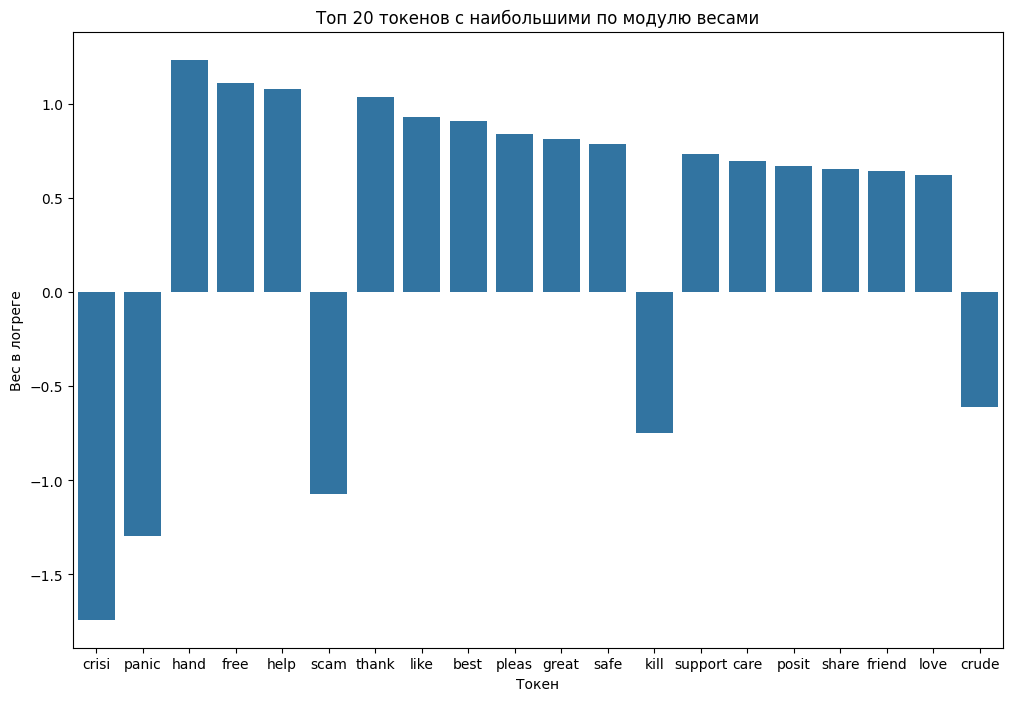

In [99]:
plt.figure(figsize=(12, 8))

sns.barplot(x=tokens, y=weights)
plt.title('Топ 20 токенов с наибольшими по модулю весами')
plt.ylabel('Вес в логреге')
plt.xlabel('Токен')
plt.show()

**Ответ:** ну тут очень логичные результаты. Т.к. чем больше отступ будет уходить в отрицательную зону, тем больше наш классификатор будет уверен в том, что данный объект отрицательного класса (в нашем случае это означает негативный отзыв), то тут мы так и видим:

- критика, паника, скам, kill и т.д. имеет отрицательный вес, потому что вероятнее всего они будут в негативном отызве
- свобода, помощь, сэнкь, лайк, бест, греат, саппорт и т.д. имеют супер положительные, т.к. они будут в положительных отзывах

## Задание 7 Другие признаки (1.5 балла)

Мы были сконцентрированы на работе с текстами твиттов и не использовали другие признаки - имена пользователя, дату и местоположение

In [100]:
train.sample(5)

,UserName,ScreenName,Location,TweetAt,OriginalTweet,Sentiment
12316,18731,63683,"Manchester, England",22-03-2020,wonder how long it'll take until they start wr...,0
33136,44562,89514,Paris,13-04-2020,consumer alert: beware of new coronavirus text...,0
13183,19794,64746,"Lexington, Kentucky",22-03-2020,this is the best news i've heard in a long tim...,1
6395,11563,56515,London,19-03-2020,we still donãât know what the medium- &amp; ...,1
15682,22871,67823,NYC/LIC,24-03-2020,campbell soup co. tells investors in an sec fi...,1


Изучите признаки UserName и ScreenName. полезны ли они? Если полезны, то закодируйте их, добавьте к матрице с отскалированными признаками, обучите логистическую регрессию, замерьте качество.

__ОТВЕТ:__ да чет вообще не вижу смысла кодировать (лол, как? ван хоттером что ли) или в целом как-то использовать эти признаки, они фулл юзлесс для определения тональности твитта.

Изучите признак TweetAt в обучающей выборке: преобразуйте его к типу datetime и нарисуйте его гистограмму с разделением по цвету на основе целевой переменной. Полезен ли он? Если полезен, то закодируйте его, добавьте к матрице с отскалированными признаками, обучите логистическую регрессию, замерьте качество.

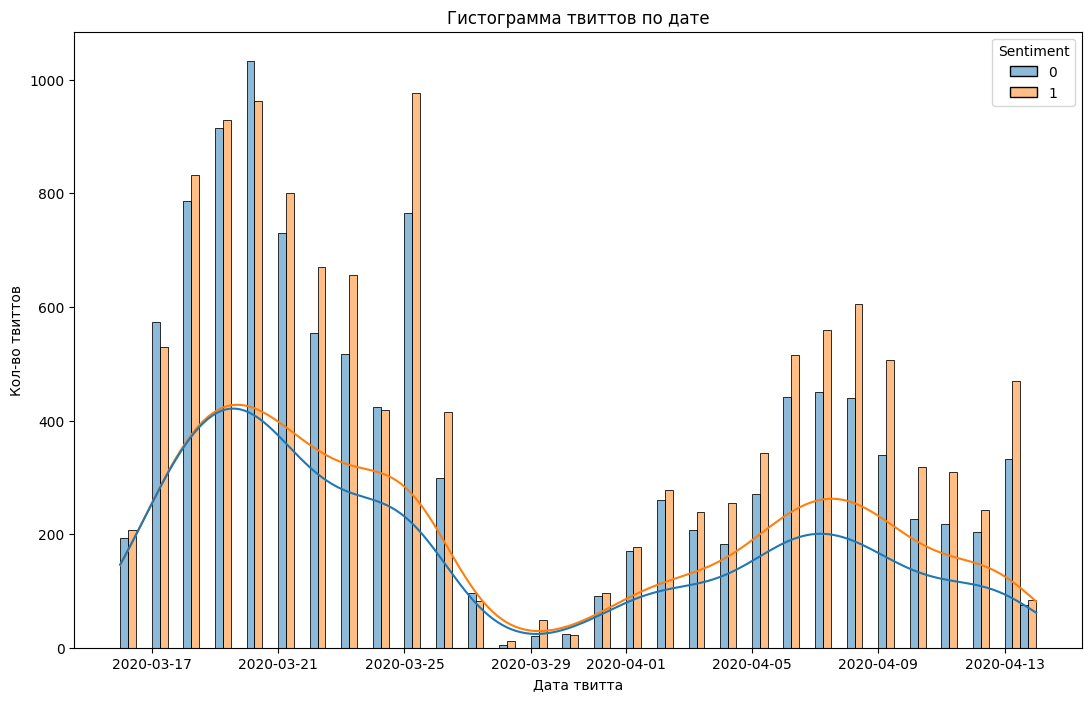

In [142]:
plt.figure(figsize=(13, 8))
train['TweetAt'] = pd.to_datetime(train['TweetAt'], format='%d-%m-%Y')
sns.histplot(data=train, x='TweetAt', hue='Sentiment', multiple='dodge', binwidth=0.5, kde=True)
plt.xlabel('Дата твитта')
plt.ylabel('Кол-во твиттов')
plt.title('Гистограмма твиттов по дате')
plt.show()

**Ответ:** хз, ничего полезного. Если бы в период 2020-03-29 каких-то твиттов было сильно больше, то мб закинуть можно, ну а так распределение симметричное относительно друг друга, никакой новой инфы.



Поработайте с признаком Location в обучающей выборке. Сколько уникальных значений?

In [119]:
train['Location'].nunique()

7949

Постройте гистограмму топ-10 по популярности местоположений (исключая Unknown)

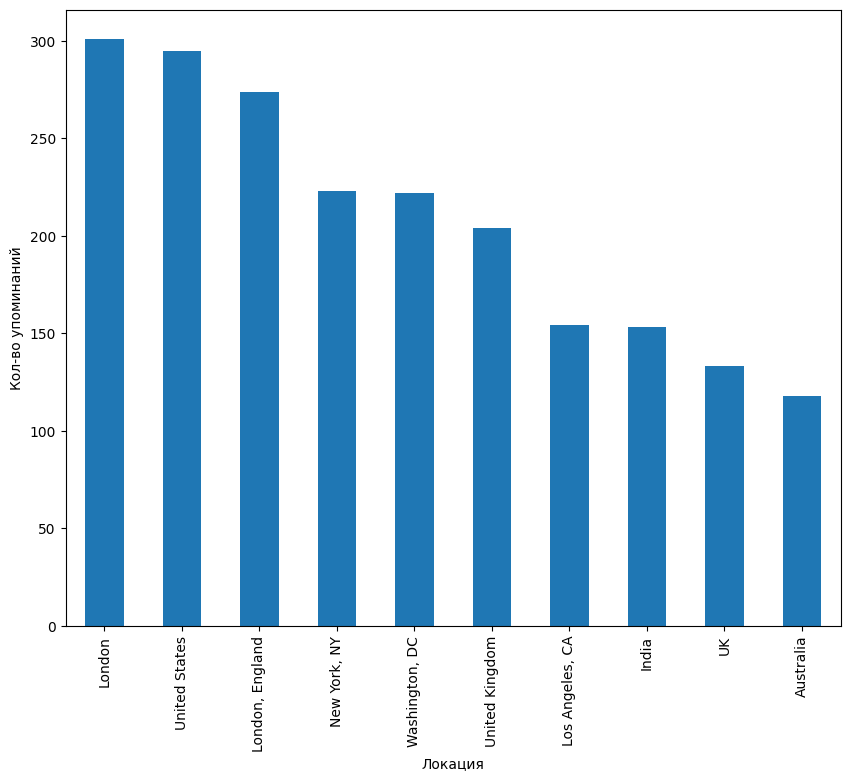

In [143]:
toplocations = train[train['Location'] != 'Unknown']['Location'].value_counts(ascending=False).head(10)
toplocations.plot(kind='bar', figsize=(10, 8))

plt.ylabel('Кол-во упоминаний')
plt.xlabel('Локация')
plt.show()

Видно, что многие местоположения включают в себя более точное название места, чем другие (Например, у некоторых стоит London, UK; а у некоторых просто UK или United Kingdom).

Создайте новый признак WiderLocation, который содержит самое широкое местоположение (например, из London, UK должно получиться UK). Сколько уникальных категорий теперь? Постройте аналогичную гистограмму.

In [188]:
def spliter(text: str):
    if ',' in text:
        return text.rsplit(sep=', ', maxsplit=1)[-1]
    else:
        return text
    
train['WiderLocation'] = train['Location'].apply(spliter)
test['WiderLocation'] = train['Location'].apply(spliter)

In [191]:
train['WiderLocation'].sample(10)

15079           England
1899                 NY
17211            Uganda
25446    United Kingdom
28374           Hungary
23074               USA
11588           Germany
19916           Unknown
27926               USA
3748          Australia
Name: WiderLocation, dtype: object

In [192]:
train.loc[train['Location'] != 'Unknown', 'WiderLocation'].nunique()

4920

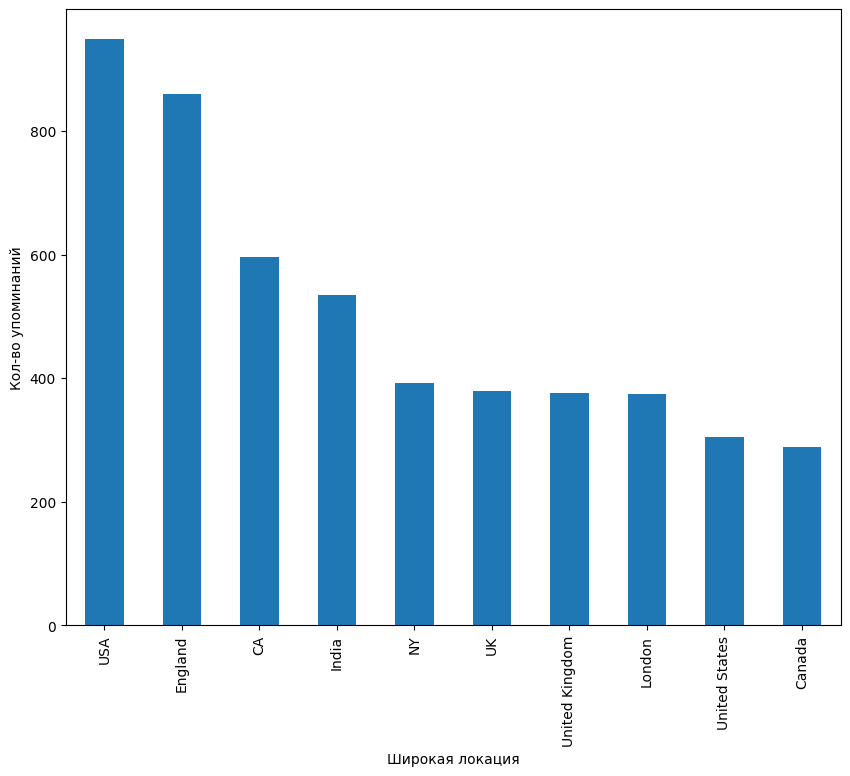

In [193]:
toplocations = train[train['Location'] != 'Unknown']['WiderLocation'].value_counts(ascending=False).head(10)
toplocations.plot(kind='bar', figsize=(10, 8))

plt.ylabel('Кол-во упоминаний')
plt.xlabel('Широкая локация')
plt.show()

Закодируйте признак WiderLocation с помощью OHE таким образом, чтобы создались только столбцы для местоположений, которые встречаются более одного раза. Сколько таких значений?


In [186]:
from sklearn.preprocessing import OneHotEncoder

WiderLocation = train.loc[train['WiderLocation'] != 'Unknown', 'WiderLocation'].value_counts(ascending=False)
WiderLocation_more_1 = WiderLocation[WiderLocation > 1]
ohe = OneHotEncoder()
location_encoded = ohe.fit_transform([WiderLocation_more_1])

In [187]:
print(f'Таких значений ровно {location_encoded.shape[1]}')

Таких значений ровно 1009


Добавьте этот признак к матрице отскалированных текстовых признаков, обучите логистическую регрессию, замерьте качество. Как оно изменилось? Оказался ли признак полезным?


*Подсказка:* используйте параметр `categories` в энкодере.

In [ ]:
from scipy.sparse import csr_matrix, hstack

# csr_matrix(WiderLocation_more_1.values.reshape(-1, 1))
# hstack([x_train_df_scaled, csr_matrix(WiderLocation_more_1.values.reshape(-1, 1))])

ohe_model = OneHotEncoder(categories=[WiderLocation_more_1.index.tolist()], handle_unknown='ignore', sparse_output=True)
wide_locations_coded_train = ohe_model.fit_transform(train[['WiderLocation']])
wide_locations_coded_test = ohe_model.transform(test[['WiderLocation']])

x_train_df_scaled = hstack([x_train_df_scaled, wide_locations_coded_train])
x_test_df_scaled = hstack([x_test_df_scaled, wide_locations_coded_test])

In [209]:
final_logreg = LogisticRegression(max_iter=1000).fit(x_train_df_scaled, y_train)
y_pred_final_train = final_logreg.predict(x_train_df_scaled)
y_pred_final_test = final_logreg.predict(x_test_df_scaled)
print(f'Качество на обучающей выборке {accuracy_score(y_train, y_pred_final_train)}, качество на тесте - {accuracy_score(y_test, y_pred_final_test)}')

Качество на обучающей выборке 0.9449807774455361, качество на тесте - 0.8437313135339845


**Ответ:** качество на обучающей выросло на 2%, а на тесте сократилось на столько же. В общем и целом игра не стоила свечь, ничего не поменялось по большей части, признак бесполезен